In [1]:
import pandas as pd 
import numpy as np

from os.path import join
import os
from tqdm import tqdm
import pandas as pd
import numpy as np


pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', 10)
from IPython.display import HTML, display
css_style = """
<style>
.scrollable {
    max-height: 1000px; 
    overflow-y: auto;
    position: relative;
}

/* Make the table header sticky */
.scrollable thead th {
    position: sticky;
    top: 0;
    background: rgba(100, 100, 100, 100); 
    z-index: 1;
}


::-webkit-scrollbar {
    -webkit-appearance: none;
}

::-webkit-scrollbar:vertical {
    width: 12px;
}

::-webkit-scrollbar-thumb {
    background-color: rgba(0, 0, 0, .5);
    border-radius: 10px;
    border: 2px solid #ffffff;
}
</style>
"""

def show(df):
    html = css_style + df.to_html(border=0)
    display(HTML('<div class="scrollable">' + html + '</div>'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


newl = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')

clinical_data = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/clinical_data/verosdata.csv')
clinical_data['taille_m'] = clinical_data['taille_cm'] / 100
clinical_data['bmi'] = clinical_data['poids_kg'] / (clinical_data['taille_m'] ** 2)
clinical_data['bmi'] = (clinical_data['bmi'] > 18.5).astype(int)
clinical_data['age'] = (clinical_data['age'] > 40).astype(int)
clinical_data['hiv_test_confirm'].fillna(1)
#clinical_data['record_id'] = clinical_data['record_id'].str.split('-').str[1].astype(int)
#clinical_data.index = clinical_data['indices']

symptoms = ['record_id','chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']
d = clinical_data[symptoms]
#show(d)
lus_interpretations = clinical_data[['record_id', 'lus_qasd_1_final',
 'lus_qasd_2_final',
 'lus_qaid_1_final',
 'lus_qsld_2_final',
 'lus_qld_1_final',
 'lus_qasg_1_final',
 'lus_qasg_2_final',
 'lus_qaig_1_final',
 'lus_qslg_2_final',
 'lus_qlg_1_final',
 'lus_qpsd_1_final',
 'lus_qpid_1_final',
 'lus_qpsg_1_final',
 'lus_qpig_1_final']]


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
def nice_plot_settings(font_size=14, font_family='STIXGeneral', mathtext_fontset='stix', usetex=False):
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 8))
    matplotlib.rcParams['mathtext.fontset'] = mathtext_fontset
    matplotlib.rcParams['font.family'] = font_family
    matplotlib.rcParams['text.usetex'] = usetex
    matplotlib.rcParams['font.size'] = font_size
    matplotlib.rcParams['axes.labelweight'] = 'bold'
    matplotlib.rcParams['axes.labelcolor'] = 'black'
    matplotlib.rcParams['axes.labelsize'] = font_size + 2
    matplotlib.rcParams['axes.titlesize'] = 'x-large'
    matplotlib.rcParams['axes.titleweight'] = 'bold'
    matplotlib.rcParams['axes.titlecolor'] = 'black'
    matplotlib.rcParams['xtick.color'] = 'black'
    matplotlib.rcParams['ytick.color'] = 'black'
    matplotlib.rcParams['legend.fontsize'] = 'medium'

nice_plot_settings()

<Figure size 1000x800 with 0 Axes>

In [4]:
clinical_data.columns.tolist()

['record_id',
 'no_tb_v2',
 'clinical_tb_v2',
 'confirmed_tb_v2',
 'lus_qasd_1_final',
 'lus_qasd_2_final',
 'lus_qaid_1_final',
 'lus_qsld_2_final',
 'lus_qld_1_final',
 'lus_qasg_1_final',
 'lus_qasg_2_final',
 'lus_qaig_1_final',
 'lus_qslg_2_final',
 'lus_qlg_1_final',
 'lus_qpsd_1_final',
 'lus_qpid_1_final',
 'lus_qpsg_1_final',
 'lus_qpig_1_final',
 'interprtation_lus_final_complete',
 'fash_pericard_effusion_final',
 'fash_adp_final',
 'fash_rpleural_effusion_final',
 'fash_liver_final',
 'fash_morison_ascites_final',
 'fash_lpleural_effusion_final',
 'fash_spleen_final',
 'fash_splenoren_ascites_final',
 'fash_douglas_ascites_final',
 'interprtation_fash_final_complete',
 'date_inclus',
 'chief_complaint',
 'fever_sympt_onset',
 'cough_sympt_onset',
 'dyspnea_sympt_onset',
 'chestpain_symp_onset',
 'hemoptysis_sympt_onset',
 'chief_complaint_other',
 'accompanying_symptoms___1',
 'accompanying_symptoms___2',
 'accompanying_symptoms___3',
 'accompanying_symptoms___4',
 'accompa

In [2]:
colsformultivariate = [
    'record_id', 'TB Label', '3 B-lines_APXD', '3 B-lines_APXG', '3 B-lines_QAID', '3 B-lines_QAIG',
    '3 B-lines_QASD', '3 B-lines_QASG', '3 B-lines_QLD', '3 B-lines_QLG', '3 B-lines_QPID', '3 B-lines_QPIG',
    '3 B-lines_QPSD', '3 B-lines_QPSG', '3 B-lines_QSLD', '3 B-lines_QSLG', 'A-lines_APXD', 'A-lines_APXG',
    'A-lines_QAID', 'A-lines_QAIG', 'A-lines_QASD', 'A-lines_QASG', 'A-lines_QLD', 'A-lines_QLG', 'A-lines_QPID',
    'A-lines_QPIG', 'A-lines_QPSD', 'A-lines_QPSG', 'A-lines_QSLD', 'A-lines_QSLG', 'Coalescing B-lines_APXD',
    'Coalescing B-lines_APXG', 'Coalescing B-lines_QAID', 'Coalescing B-lines_QAIG', 'Coalescing B-lines_QASD',
    'Coalescing B-lines_QASG', 'Coalescing B-lines_QLD', 'Coalescing B-lines_QLG', 'Coalescing B-lines_QPID',
    'Coalescing B-lines_QPIG', 'Coalescing B-lines_QPSD', 'Coalescing B-lines_QPSG', 'Coalescing B-lines_QSLD',
    'Coalescing B-lines_QSLG', 'Large Consolidations_APXD', 'Large Consolidations_APXG', 'Large Consolidations_QAID',
    'Large Consolidations_QAIG', 'Large Consolidations_QASD', 'Large Consolidations_QASG', 'Large Consolidations_QLD',
    'Large Consolidations_QLG', 'Large Consolidations_QPID', 'Large Consolidations_QPIG', 'Large Consolidations_QPSD',
    'Large Consolidations_QPSG', 'Large Consolidations_QSLD', 'Large Consolidations_QSLG', 'Pattern A (pneumothorax)_APXD',
    'Pattern A (pneumothorax)_APXG', 'Pattern A (pneumothorax)_QAID', 'Pattern A (pneumothorax)_QAIG',
    'Pattern A (pneumothorax)_QASD', 'Pattern A (pneumothorax)_QASG', 'Pattern A (pneumothorax)_QLD',
    'Pattern A (pneumothorax)_QLG', 'Pattern A (pneumothorax)_QPID', 'Pattern A (pneumothorax)_QPIG',
    'Pattern A (pneumothorax)_QPSD', 'Pattern A (pneumothorax)_QPSG', 'Pattern A (pneumothorax)_QSLD',
    'Pattern A (pneumothorax)_QSLG', 'Pleural effusion_APXD', 'Pleural effusion_APXG', 'Pleural effusion_QAID',
    'Pleural effusion_QAIG', 'Pleural effusion_QASD', 'Pleural effusion_QASG', 'Pleural effusion_QLD',
    'Pleural effusion_QLG', 'Pleural effusion_QPID', 'Pleural effusion_QPIG', 'Pleural effusion_QPSD',
    'Pleural effusion_QPSG', 'Pleural effusion_QSLD', 'Pleural effusion_QSLG', 'Small consolidations and or nodules_APXD',
    'Small consolidations and or nodules_APXG', 'Small consolidations and or nodules_QAID', 'Small consolidations and or nodules_QAIG',
    'Small consolidations and or nodules_QASD', 'Small consolidations and or nodules_QASG', 'Small consolidations and or nodules_QLD',
    'Small consolidations and or nodules_QLG', 'Small consolidations and or nodules_QPID', 'Small consolidations and or nodules_QPIG',
    'Small consolidations and or nodules_QPSD', 'Small consolidations and or nodules_QPSG', 'Small consolidations and or nodules_QSLD',
    'Small consolidations and or nodules_QSLG'
]

newlmv = newl[colsformultivariate]

apical_quadrants = ['APXD', 'APXG', 'QPID', 'QPIG']
anterior_quadrants = ['QASD', 'QAID', 'QASG', 'QAIG']
posterior_quadrants = ['QPSD', 'QPSG', 'QLD', 'QLG']
lateral_quadrants = ['QSLD', 'QSLG']
non_apical_quadrant = anterior_quadrants + posterior_quadrants + lateral_quadrants

patterns = ['3 B-lines', 'A-lines', 'Coalescing B-lines', 'Large Consolidations', 'Pattern A (pneumothorax)', 'Pleural effusion', 'Small consolidations and or nodules']

def combine_columns_max(df, pattern, quadrants):
    columns = [f"{pattern}_{q}" for q in quadrants]
    return df[columns].max(axis=1)

combined_df = pd.DataFrame()
combined_df['record_id'] = newlmv['record_id']
combined_df['TB Label'] = newlmv['TB Label']

for pattern in patterns:
    combined_df[f"{pattern}_Apical"] = combine_columns_max(newlmv, pattern, apical_quadrants)
    #combined_df[f"{pattern}_Anterior"] = combine_columns_max(newlmv, pattern, anterior_quadrants)
    #combined_df[f"{pattern}_Posterior"] = combine_columns_max(newlmv, pattern, posterior_quadrants)
    #combined_df[f"{pattern}_Lateral"] = combine_columns_max(newlmv, pattern, lateral_quadrants)
    combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(newlmv, pattern, non_apical_quadrant)



clin_df = ['record_id', 'TB Label', 'chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']

# clin_df = ['record_id',  'chief_complaint',
# 'chief_complaint_other',
#  'accompanying_symptoms___1',
#  'accompanying_symptoms___2',
#  'accompanying_symptoms___3',
#  'accompanying_symptoms___4',
#  'accompanying_symptoms___5',
#  'accompanying_symptoms___6',
#  'accompanying_symptoms___7',
#  'accompanying_symptoms___8',
#  'accompanying_symptoms___9',
#  'accompanying_symptoms___10',
#  'accompanying_symptoms___11',
#  'accompanying_symptoms___12',
#  'accompanying_symptoms___13',
# 'fever_acc_sympt_duration',
#  'cough_acc_sympt_duration',
#  'weight_acc_sympt_duration',
#  'dyspnea_acc_sympt_duration',
#  'chest_acc_sympt_duration',
#  'hemopt_acc_sympt_duration',
#  'sweats_acc_sympt_duration',
#  'asthen_acc_sympt_duration',
#  'anorex_acc_sympt_duration',
#  'pharyn_acc_sympt_duration',
#  'git_acc_sympt_duration',
#  'taste_acc_sympt_duration',
#   'other_acc_symp_duration',
#  'chronic_cough',
# 'smoker',
# 'diabetes',
#  'hypertension',
#  'cardiopathy',
# 'sexe','bmi', 'age', 'hiv_test_confirm',
#             'quick_sofa_score'
#]

clin_df = ['record_id',  'chief_complaint',
'chief_complaint_other',
 'accompanying_symptoms___1',
 'accompanying_symptoms___2',
 'accompanying_symptoms___3',
 'accompanying_symptoms___4',
 'accompanying_symptoms___5',
 'accompanying_symptoms___6',
 'accompanying_symptoms___7',
 'accompanying_symptoms___8',
 'accompanying_symptoms___9',
 'accompanying_symptoms___10',
 'accompanying_symptoms___11',
 'accompanying_symptoms___12',
 'accompanying_symptoms___13',
'fever_acc_sympt_duration',
 'cough_acc_sympt_duration',
 'weight_acc_sympt_duration',
 'dyspnea_acc_sympt_duration',
 'chest_acc_sympt_duration',
 'hemopt_acc_sympt_duration',
 'sweats_acc_sympt_duration',
 'asthen_acc_sympt_duration',
 'anorex_acc_sympt_duration',
 'pharyn_acc_sympt_duration',
 'git_acc_sympt_duration',
 'taste_acc_sympt_duration',
  'other_acc_symp_duration',
 'chronic_cough',
'smoker',
'diabetes',
 'hypertension',
 'cardiopathy',
'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score'
]

# d = clinical_data[clin_df].fillna(0)
# combined_df = pd.merge(combined_df, d, left_on='record_id', right_on='record_id')


# combined_df = combined_df[clin_df]
# if 'TB Label' not in combined_df.columns.tolist():
#      combined_df['TB Label'] = newlmv['TB Label']

In [3]:
combined_df

,record_id,TB Label,3 B-lines_Apical,3 B-lines_AnyQuadrant,A-lines_Apical,A-lines_AnyQuadrant,Coalescing B-lines_Apical,Coalescing B-lines_AnyQuadrant,Large Consolidations_Apical,Large Consolidations_AnyQuadrant,Pattern A (pneumothorax)_Apical,Pattern A (pneumothorax)_AnyQuadrant,Pleural effusion_Apical,Pleural effusion_AnyQuadrant,Small consolidations and or nodules_Apical,Small consolidations and or nodules_AnyQuadrant
0,25-1,0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,25-101,1,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,25-102,1,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,25-103,1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,25-104,0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,25-92,0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
500,25-95,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
501,25-96,0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
502,25-97,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [70]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
data = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_2.csv')


train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]


# train_ids = data['train_indices'].dropna().tolist()
# valid_ids = data['valid_ids'].dropna().tolist()
# test_ids = data['test_ids'].dropna().tolist()

train = combined_df[combined_df['record_id'].isin(train_ids)]
valid = combined_df[combined_df['record_id'].isin(valid_ids)]
test = combined_df[combined_df['record_id'].isin(test_ids)]

In [7]:
#base_dir = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{i}.csv'

for i in range(5):
    file_path = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{i}.csv'
    data = pd.read_csv(file_path)
    train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
    valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
    test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]
    
    train = combined_df[combined_df['record_id'].isin(train_ids)]
    valid = combined_df[combined_df['record_id'].isin(valid_ids)]
    test = combined_df[combined_df['record_id'].isin(test_ids)]


0
1
2
3
4


In [7]:
ids = set()
for f in os.listdir('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/images'):
    ids.add(f.split('_')[0])
len(ids)

503

In [8]:
print(len(train) + len(valid) + len(test))

502


In [1]:
import sklearn
import xgboost

print("scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)

scikit-learn version: 1.5.1
XGBoost version: 2.1.0


Random Forest 0.8120300751879699
Random Forest 0 0.8120300751879699
Random Forest 0.8329156223893066
Random Forest 1 0.8329156223893066
Random Forest 0.8379281537176275
Random Forest 2 0.8379281537176275
Random Forest 0.843358395989975
Random Forest 3 0.843358395989975
Random Forest 0.8437761069340017
Random Forest 4 0.8437761069340017
Model: Random Forest
Mean AUROC on Test Set: 0.834
95% CI for AUROC on Test Set: [0.818, 0.850]
Logistic Regression 0.8467000835421888
Logistic Regression 0 0.8467000835421888
Logistic Regression 1 0.8387635756056809
Logistic Regression 2 0.8400167084377611
Logistic Regression 3 0.8387635756056809
Logistic Regression 4 0.8304093567251463
Model: Logistic Regression
Mean AUROC on Test Set: 0.839
95% CI for AUROC on Test Set: [0.832, 0.846]


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:46] WARNING: /workspace/src/lea

XGBoost 0.8368838763575605
XGBoost 0 0.8368838763575605


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:47] WARNING: /workspace/src/lea

XGBoost 1 0.814327485380117


...

XGBoost 2 0.8191311612364243


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:48] WARNING: /workspace/src/lea

XGBoost 3 0.8020050125313284


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:33:49] WARNING: /workspace/src/lea

XGBoost 4 0.8157894736842104
Model: XGBoost
Mean AUROC on Test Set: 0.818
95% CI for AUROC on Test Set: [0.802, 0.833]


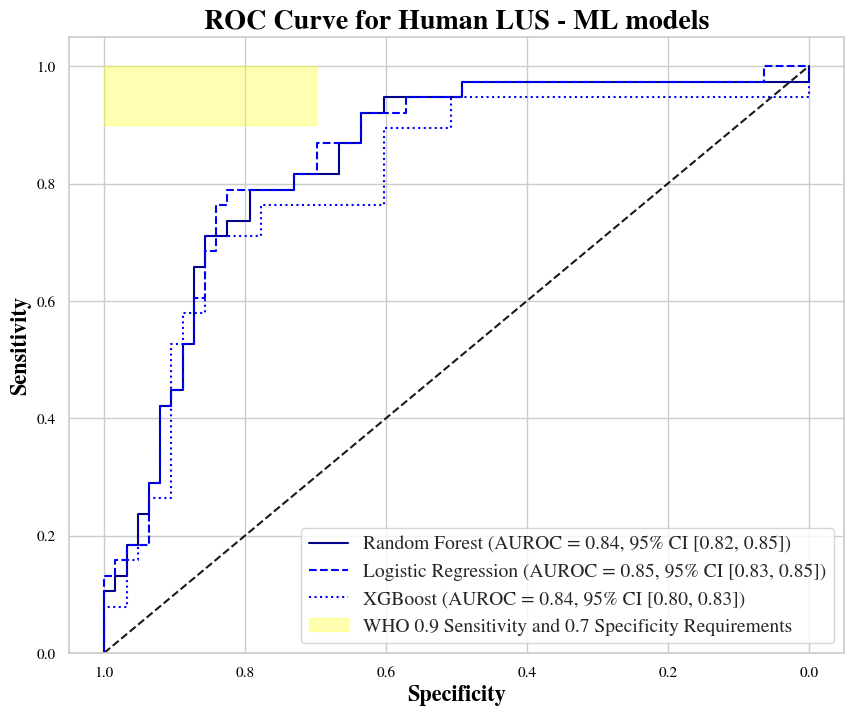

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import pickle
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import scipy.stats
from sklearn.linear_model import LogisticRegression

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h


    # X_train_full = pd.concat([X_train_orig, X_valid])
    # y_train_full = pd.concat([y_train, y_valid])

# Standardize the data
    #scaler = StandardScaler()
    #X_train_full = scaler.fit_transform(X_train_full)
    #X_test = scaler.transform(X_test)

# Define parameter grids for each model
param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

param_grid_lgb = {
    'lgb__n_estimators': [50, 100, 200],
    'lgb__learning_rate': [0.01, 0.1, 0.2],
    'lgb__max_depth': [3, 5, 7]
}

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}

param_grid_ab = {
    'ab__n_estimators': [50, 100, 200],
    'ab__learning_rate': [0.01, 0.1, 0.2]
}

param_grid_cb = {
    'cb__iterations': [50, 100, 200],
    'cb__learning_rate': [0.01, 0.1, 0.2],
    'cb__depth': [3, 5, 7]
}

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100]
}

# Create model pipelines
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(max_iter=10000))
])

rf_pipeline = Pipeline([
    #('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

ab_pipeline = Pipeline([
    #('scaler', StandardScaler()),
    ('ab', AdaBoostClassifier())
])

xgb_pipeline = Pipeline([
    #('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

lgb_pipeline = Pipeline([
    #('scaler', StandardScaler()),
    ('lgb', lgb.LGBMClassifier())
])

cb_pipeline = Pipeline([
# ('scaler', StandardScaler()),
    ('cb', CatBoostClassifier(verbose=0))
])

models = {
    'Random Forest': (rf_pipeline, param_grid_rf),
    #'AdaBoost': (ab_pipeline, param_grid_ab),
    #'CatBoost': (cb_pipeline, param_grid_cb),
    'Logistic Regression': (lr_pipeline, param_grid_lr),
    'XGBoost': (xgb_pipeline, param_grid_xgb),
    #'LightGBM': (lgb_pipeline, param_grid_lgb)
}

# Initialize StratifiedKFold
#k = 5
#skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
file_path = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_0.csv'
data = pd.read_csv(file_path)
train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]
test = combined_df[combined_df['record_id'].isin(test_ids)]
rf_folds_test_preds = pd.DataFrame()
rf_folds_test_preds['record_id'] = test['record_id']

folds_preds_df = pd.DataFrame()
folds_preds_df['record_id'] = test['record_id']
folds_preds_df['TB Label'] = test['TB Label']

results = {}
best_models = {}


for model_name, (pipeline, param_grid) in models.items():
    test_aurocs = []
    fold_predictions = []
    best_test_auc = 0
    for i in range(5):
        file_path = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{i}.csv'
        data = pd.read_csv(file_path)
        train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
        valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
        test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]
        
        train = combined_df[combined_df['record_id'].isin(train_ids)]
        valid = combined_df[combined_df['record_id'].isin(valid_ids)]
        test = combined_df[combined_df['record_id'].isin(test_ids)]

        X_train_orig, y_train, y_train_ids = train.drop(columns=['record_id', 'TB Label']), train['TB Label'], train['record_id']
        X_valid, y_valid, y_valid_ids = valid.drop(columns=['record_id', 'TB Label']), valid['TB Label'], valid['record_id']
        X_test, y_test_m, y_test_ids = test.drop(columns=['record_id', 'TB Label']), test['TB Label'], test['record_id']
        features = ['Large Consolidations_AnyQuadrant', 'Large Consolidations_Apical', 'Small consolidations and or nodules_Apical', '3 B-lines_Apical', 'A-lines_Apical', 'A-lines_AnyQuadrant', 'Coalescing B-lines_AnyQuadrant', 'Coalescing B-lines_Apical', 'Small consolidations and or nodules_AnyQuadrant']
        X_train_orig = X_train_orig[features]
        X_test = X_test[features]



    #for fold, (train_index, valid_index) in enumerate(skf.split(X_train_full, y_train_full)):
        #X_train_fold, X_valid_fold = X_train_full[train_index], X_train_full[valid_index]
        #y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]
        
        grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                                scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_orig, y_train)
        
        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)

        # y_test_pred_proba = best_model.predict_proba(X_valid_fold)[:, 1]
        # test_auc = roc_auc_score(y_valid_fold, y_test_pred_proba)
        # test_aurocs.append(test_auc)

        # if fold == 1:
        #     best_test_auc = test_auc
        #     best_models[model_name] = best_model

        if test_auc > best_test_auc:
            print(model_name, test_auc)
            best_test_auc = test_auc
            best_models[model_name] = best_model

        folds_preds_df[f'{model_name}_Fold_{i}'] = y_test_pred_proba
        print(model_name, i, test_auc)

    
    mean_auc, ci_lower, ci_upper = mean_confidence_interval(test_aurocs)
    results[model_name] = (mean_auc, ci_lower, ci_upper)
    
    print(f"Model: {model_name}")
    print(f"Mean AUROC on Test Set: {mean_auc:.3f}")
    print(f"95% CI for AUROC on Test Set: [{ci_lower:.3f}, {ci_upper:.3f}]")


# Evaluate the best models on the test set
predictions = {}
for model_name, (mean_auc, ci_lower, ci_upper) in results.items():
    model = best_models[model_name]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred_proba

# Save predictions to a file
with open('model_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Plot the AUROC curve

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

plt.figure(figsize=(10, 8))

results_df = pd.DataFrame({
    'record_id': y_test_ids,
    'y_test': y_test_m
})

colors = {
    'Random Forest': '#00008B',  # Dark Blue
    'Logistic Regression': '#0000FF',  # Medium Blue
    'XGBoost': '#0000FF'  # Light Blue
}

linestyles = {
    'Random Forest': '-',
    'Logistic Regression': '--',
    'XGBoost': ':'
}

for model_name, y_pred_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test_m, y_pred_proba)
    auroc = roc_auc_score(y_test_m, y_pred_proba)
    mean_auc, ci_lower, ci_upper = results[model_name]
    results_df[f'{model_name}_pred_proba'] = y_pred_proba
    results_df[f'{model_name}_fpr'] = pd.Series(fpr, index=results_df.index[:len(fpr)])
    results_df[f'{model_name}_tpr'] = pd.Series(tpr, index=results_df.index[:len(tpr)])
    plt.plot(fpr, tpr, label=f'{model_name} (AUROC = {auroc:.2f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}])', color=colors[model_name], linestyle=linestyles[model_name], drawstyle='steps-post')


plt.plot([0, 1], [0, 1], 'k--')
highlight = plt.axvspan(0, 0.3, ymin=0.9/1.05, ymax=1/1.05, color='yellow', alpha=0.3)


highlight_patch = Patch(color='yellow', alpha=0.3, label='WHO 0.9 Sensitivity and 0.7 Specificity Requirements')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles + [highlight_patch], loc="lower right")

xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xtick_labels = ['1.0', '0.8', '0.6', '0.4', '0.2', '0.0']
plt.xticks(xticks, labels=xtick_labels)
#plt.xlim([0.0, 1.0])c
plt.xticks(xticks)
plt.ylim([0.0, 1.05])
plt.xlabel('Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve for Human LUS - ML models')
plt.savefig('auroc_curve_mlmodels.png')
plt.show()

In [15]:
results_df

,record_id,y_test,Random Forest_pred_proba,Random Forest_fpr,Random Forest_tpr,Logistic Regression_pred_proba,Logistic Regression_fpr,Logistic Regression_tpr,XGBoost_pred_proba,XGBoost_fpr,XGBoost_tpr
3,25-103,1,0.451406,0.000000,0.000000,0.315955,0.000000,0.000000,0.164872,0.000000,0.000000
5,25-106,1,0.180751,0.000000,0.026316,0.344040,0.000000,0.026316,0.258803,0.000000,0.026316
6,25-108,1,0.765050,0.000000,0.157895,0.445292,0.000000,0.131579,0.658898,0.000000,0.131579
17,25-120,1,0.181994,0.015873,0.157895,0.337757,0.015873,0.131579,0.349441,0.031746,0.131579
21,25-128,0,0.368262,0.015873,0.210526,0.359996,0.015873,0.157895,0.385496,0.031746,0.184211
...,...,...,...,...,...,...,...,...,...,...,...
488,25-80,0,0.250223,NaN,NaN,0.385848,NaN,NaN,0.265409,NaN,NaN
490,25-82,1,0.569347,NaN,NaN,0.436837,NaN,NaN,0.600146,NaN,NaN
493,25-87,0,0.197566,NaN,NaN,0.336697,NaN,NaN,0.349441,NaN,NaN
496,25-9,0,0.042310,NaN,NaN,0.292964,NaN,NaN,0.095236,NaN,NaN


In [16]:
folds_preds_df

,record_id,TB Label,Random Forest_Fold_0,Random Forest_Fold_1,Random Forest_Fold_2,Random Forest_Fold_3,Random Forest_Fold_4,Logistic Regression_Fold_0,Logistic Regression_Fold_1,Logistic Regression_Fold_2,Logistic Regression_Fold_3,Logistic Regression_Fold_4,XGBoost_Fold_0,XGBoost_Fold_1,XGBoost_Fold_2,XGBoost_Fold_3,XGBoost_Fold_4
3,25-103,1,0.400759,0.451406,0.323718,0.236646,0.330791,0.315955,0.300646,0.168274,0.300225,0.305752,0.345357,0.148169,0.183871,0.198658,0.164872
5,25-106,1,0.261626,0.180751,0.276748,0.289335,0.274044,0.344040,0.325425,0.245216,0.341102,0.343755,0.284199,0.185469,0.295451,0.292607,0.258803
6,25-108,1,0.601710,0.765050,0.636235,0.506889,0.582869,0.445292,0.452076,0.555090,0.435574,0.444262,0.651727,0.746583,0.575464,0.724137,0.658898
17,25-120,1,0.153562,0.181994,0.240423,0.272696,0.246627,0.337757,0.319035,0.222788,0.330276,0.336550,0.215881,0.223799,0.330349,0.124828,0.349441
21,25-128,0,0.324478,0.368262,0.390511,0.379714,0.421530,0.359996,0.346022,0.311821,0.366107,0.366798,0.242200,0.421613,0.374941,0.448619,0.385496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,25-80,0,0.174563,0.250223,0.279205,0.419190,0.283784,0.385848,0.375917,0.361064,0.404753,0.390664,0.112973,0.268689,0.337708,0.487656,0.265409
490,25-82,1,0.627856,0.569347,0.642411,0.546420,0.606026,0.436837,0.438091,0.557150,0.448010,0.439610,0.563265,0.535030,0.489714,0.688693,0.600146
493,25-87,0,0.245617,0.197566,0.261441,0.281638,0.287146,0.336697,0.318752,0.229580,0.330121,0.339633,0.252156,0.223799,0.330349,0.291108,0.349441
496,25-9,0,0.030348,0.042310,0.042197,0.113290,0.061216,0.292964,0.282891,0.129348,0.270816,0.289411,0.068774,0.088195,0.183871,0.072911,0.095236


In [17]:
folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')

In [18]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/mlresults3.csv')

In [67]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clin_randomforestresults2.csv')
folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clinFoldsPreds3.csv')

In [15]:
transformed_data = {
    'Model Name': ['Random Forest', 'Xgboost',  'Logistic Regression',],
    'Mean AUROC': [
        results['Random Forest'][0],
        results['XGBoost'][0],
        results['Logistic Regression'][0]
    ],
    'Lower CI': [
        results['Random Forest'][1],
        results['XGBoost'][1],
        results['Logistic Regression'][1]
    ],
    'Upper CI': [
        results['Random Forest'][2],
        results['XGBoost'][2],
        results['Logistic Regression'][2]
    ]
}
transformed_data

{'Model Name': ['Random Forest', 'Xgboost', 'Logistic Regression'],
 'Mean AUROC': [0.8467000835421887, 0.8329991645781121, 0.839390142021721],
 'Lower CI': [0.8379058323266659, 0.8263505407241272, 0.8286256736508709],
 'Upper CI': [0.8554943347577115, 0.839647788432097, 0.8501546103925711]}

In [58]:
data = {
    'Model Name': ['Random Forest', 'AdaBoost', 'CatBoost', 'Logistic Regression'],
    'Mean AUROC': [0.9122994652406418, 0.8878074866310162, 0.902139037433155, 0.8902673796791445],
    'Lower CI': [0.9028974777079831, 0.884076410058633, 0.8831426147500581, 0.8862723798253831],
    'Upper CI': [0.9217014527733004, 0.8915385632033993, 0.921135460116252, 0.8942623795329059]
}

# Create DataFrame
df = pd.DataFrame(transformed_data)
df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/mlConfidenceIntervals2.csv')

In [59]:
folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/mlFoldsPreds2.csv')

In [19]:
rf_model = best_models['Random Forest'].named_steps['rf']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train_orig.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feature_importance_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/RandomForestFeatureImportances2.csv')
show(feature_importance_df)

,Feature,Importance
7,Large Consolidations_AnyQuadrant,0.417832
6,Large Consolidations_Apical,0.256636
12,Small consolidations and or nodules_Apical,0.063665
0,3 B-lines_Apical,0.048582
2,A-lines_Apical,0.040532
3,A-lines_AnyQuadrant,0.036045
5,Coalescing B-lines_AnyQuadrant,0.030159
4,Coalescing B-lines_Apical,0.029083
1,3 B-lines_AnyQuadrant,0.025497
13,Small consolidations and or nodules_AnyQuadrant,0.021203


In [17]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/random_forest_featureselectionresults2.csv')

In [22]:
features = feature_importance_df['Feature'].tolist()
features

['Large Consolidations_AnyQuadrant',
 'Large Consolidations_Apical',
 'Small consolidations and or nodules_Apical',
 '3 B-lines_Apical',
 'A-lines_Apical',
 'A-lines_AnyQuadrant',
 'Coalescing B-lines_AnyQuadrant',
 'Coalescing B-lines_Apical',
 '3 B-lines_AnyQuadrant',
 'Small consolidations and or nodules_AnyQuadrant',
 'Pleural effusion_AnyQuadrant',
 'Pleural effusion_Apical',
 'Pattern A (pneumothorax)_AnyQuadrant',
 'Pattern A (pneumothorax)_Apical']

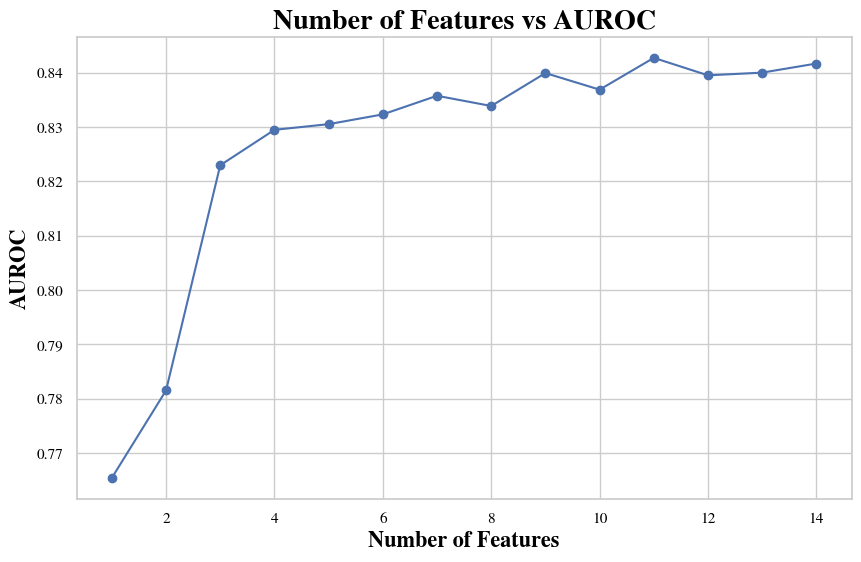

Number of features: 14
Features: ['Large Consolidations_AnyQuadrant', 'Large Consolidations_Apical', 'Small consolidations and or nodules_Apical', '3 B-lines_Apical', 'A-lines_Apical', 'A-lines_AnyQuadrant', 'Coalescing B-lines_AnyQuadrant', 'Coalescing B-lines_Apical', '3 B-lines_AnyQuadrant', 'Small consolidations and or nodules_AnyQuadrant', 'Pleural effusion_AnyQuadrant', 'Pleural effusion_Apical', 'Pattern A (pneumothorax)_AnyQuadrant', 'Pattern A (pneumothorax)_Apical']
Number of features: 13
Features: ['Large Consolidations_AnyQuadrant', 'Large Consolidations_Apical', 'Small consolidations and or nodules_Apical', '3 B-lines_Apical', 'A-lines_Apical', 'A-lines_AnyQuadrant', 'Coalescing B-lines_AnyQuadrant', 'Coalescing B-lines_Apical', '3 B-lines_AnyQuadrant', 'Small consolidations and or nodules_AnyQuadrant', 'Pleural effusion_AnyQuadrant', 'Pleural effusion_Apical', 'Pattern A (pneumothorax)_Apical']
Number of features: 12
Features: ['Large Consolidations_AnyQuadrant', 'Large C

In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pickle

# Define your initial feature set
features = feature_importance_df['Feature'].tolist()

X_train_orig, y_train, y_train_ids = train[features], train['TB Label'], train['record_id']
X_valid, y_valid, y_valid_ids = valid[features], valid['TB Label'], valid['record_id']
X_test, y_test_m, y_test_ids = test[features], test['TB Label'], test['record_id']

# Combine train and validation sets for cross-validation
X_train_full = pd.concat([X_train_orig, X_valid])
y_train_full = pd.concat([y_train, y_valid])

# Standardize the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

results = []
feature_sets = []  # List to store feature sets

feature_set = features.copy()

while len(feature_set) > 0:
    #X_train_subset = X_train_full[:, :len(feature_set)]
    #X_test_subset = X_test[:, :len(feature_set)]

    test_aurocs = []

    for i in range(5):
        file_path = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{i}.csv'
        data = pd.read_csv(file_path)
        train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
        valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
        test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]
        
        train = combined_df[combined_df['record_id'].isin(train_ids)]
        valid = combined_df[combined_df['record_id'].isin(valid_ids)]
        test = combined_df[combined_df['record_id'].isin(test_ids)]

        X_train_orig, y_train, y_train_ids = train.drop(columns=['record_id', 'TB Label']), train['TB Label'], train['record_id']
        X_valid, y_valid, y_valid_ids = valid.drop(columns=['record_id', 'TB Label']), valid['TB Label'], valid['record_id']
        X_test, y_test_m, y_test_ids = test.drop(columns=['record_id', 'TB Label']), test['TB Label'], test['record_id']

        X_train_orig = X_train_orig[feature_set]
        X_test = X_test[feature_set]

    # for train_index, valid_index in skf.split(X_train_subset, y_train_full):
    #     X_train_fold, X_valid_fold = X_train_subset[train_index], X_train_subset[valid_index]
    #     y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]

        grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid_rf, 
                                   scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_orig, y_train)

        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)

    mean_auc = np.mean(test_aurocs)
    results.append((len(feature_set), mean_auc))
    feature_sets.append(feature_set.copy())  # Save the current feature set

    # Eliminate the least important feature
    feature_importances = grid_search.best_estimator_.named_steps['rf'].feature_importances_
    least_important_feature_index = np.argmin(feature_importances)
    del feature_set[least_important_feature_index]

# Save the results and feature sets
with open('feature_elimination_results.pkl', 'wb') as f:
    pickle.dump(results, f)

with open('feature_sets.pkl', 'wb') as f:
    pickle.dump(feature_sets, f)

# Plot the results
num_features = [result[0] for result in results]
aurocs = [result[1] for result in results]

plt.figure(figsize=(10, 6))
plt.plot(num_features, aurocs, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('AUROC')
plt.title('Number of Features vs AUROC')
plt.grid(True)
plt.savefig('feature_elimination_auroc.png')
plt.show()

# Display the feature sets for each iteration
for num_features, feature_set in zip(num_features, feature_sets):
    print(f"Number of features: {num_features}")
    print(f"Features: {feature_set}")


Model: Random Forest
Mean AUROC on Test Set: 0.835
95% CI for AUROC on Test Set: [0.820, 0.850]


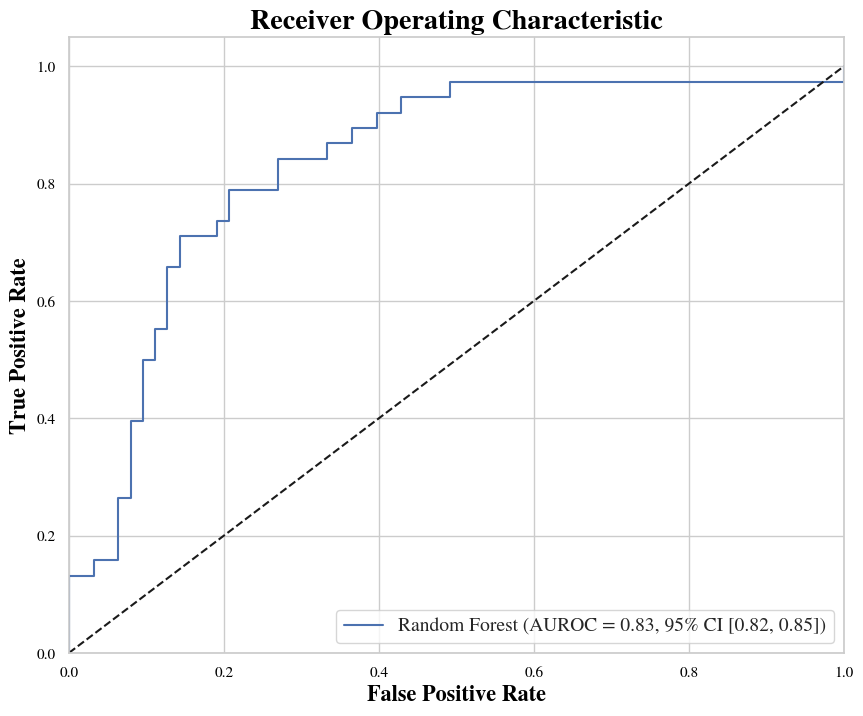

In [38]:
#features = feature_importance_df['Feature'].loc[:9].to_list()
#features = ['Large Consolidations_AnyQuadrant', 'Large Consolidations_Apical', 'Small consolidations and or nodules_Apical', '3 B-lines_Apical', 'A-lines_AnyQuadrant', 'Small consolidations and or nodules_AnyQuadrant', 'A-lines_Apical', 'Coalescing B-lines_AnyQuadrant', 'Coalescing B-lines_Apical', 'Pleural effusion_AnyQuadrant', '3 B-lines_AnyQuadrant', 'Pleural effusion_Apical']
#,
features = ['Large Consolidations_AnyQuadrant', 'Large Consolidations_Apical', 'Small consolidations and or nodules_Apical', '3 B-lines_Apical', 'A-lines_Apical', 'A-lines_AnyQuadrant', 'Coalescing B-lines_AnyQuadrant', 'Coalescing B-lines_Apical', 'Small consolidations and or nodules_AnyQuadrant']

# X_train_orig, y_train, y_train_ids = train[features], train['TB Label'], train['record_id']
# X_valid, y_valid, y_valid_ids = valid[features], valid['TB Label'], valid['record_id']
# X_test, y_test_m, y_test_ids = test[features], test['TB Label'], test['record_id']

# # Combine train and validation sets for cross-validation
# X_train_full = pd.concat([X_train_orig, X_valid])
# y_train_full = pd.concat([y_train, y_valid])

# # Standardize the data
# scaler = StandardScaler()
# X_train_full = scaler.fit_transform(X_train_full)
# X_test = scaler.transform(X_test)

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

models = {
    'Random Forest': (rf_pipeline, param_grid_rf),
}

#k = 5
#skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

rf_folds_test_preds = pd.DataFrame()
rf_folds_test_preds['record_id'] = y_test_ids

folds_preds_df = pd.DataFrame()
folds_preds_df['record_id'] = y_test_ids
folds_preds_df['TB Label'] = y_test_m

results = {}
best_models = {}


for model_name, (pipeline, param_grid) in models.items():
    test_aurocs = []
    fold_predictions = []
    best_test_auc = 0
    for i in range(5):
        file_path = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{i}.csv'
        data = pd.read_csv(file_path)
        train_ids = [str(idx) for idx in data['train_ids'].dropna().tolist()]
        valid_ids = [str(idx) for idx in data['valid_ids'].dropna().tolist()]
        test_ids = [str(idx) for idx in data['test_ids'].dropna().tolist()]
        
        train = combined_df[combined_df['record_id'].isin(train_ids)]
        valid = combined_df[combined_df['record_id'].isin(valid_ids)]
        test = combined_df[combined_df['record_id'].isin(test_ids)]

        X_train_orig, y_train, y_train_ids = train.drop(columns=['record_id', 'TB Label']), train['TB Label'], train['record_id']
        X_valid, y_valid, y_valid_ids = valid.drop(columns=['record_id', 'TB Label']), valid['TB Label'], valid['record_id']
        X_test, y_test_m, y_test_ids = test.drop(columns=['record_id', 'TB Label']), test['TB Label'], test['record_id']
        X_train_orig = X_train_orig[features]
        X_test = X_test[features]
    #for fold, (train_index, valid_index) in enumerate(skf.split(X_train_full, y_train_full)):
     #   X_train_fold, X_valid_fold = X_train_full[train_index], X_train_full[valid_index]
      #  y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]
        
        grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                                   scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_orig, y_train)
        
        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)

        if test_auc > best_test_auc:
            best_models[model_name] = best_model

        folds_preds_df[f'{model_name}_Fold_{i}'] = y_test_pred_proba

    
    mean_auc, ci_lower, ci_upper = mean_confidence_interval(test_aurocs)
    results[model_name] = (mean_auc, ci_lower, ci_upper)
    
    print(f"Model: {model_name}")
    print(f"Mean AUROC on Test Set: {mean_auc:.3f}")
    print(f"95% CI for AUROC on Test Set: [{ci_lower:.3f}, {ci_upper:.3f}]")

    predictions = {}
for model_name, (mean_auc, ci_lower, ci_upper) in results.items():
    model = best_models[model_name]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred_proba

# Save predictions to a file
with open('model_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Plot the AUROC curve

plt.figure(figsize=(10, 8))

results_df = pd.DataFrame({
    'record_id': y_test_ids,
    'y_test': y_test_m
})

for model_name, y_pred_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test_m, y_pred_proba)
    mean_auc, ci_lower, ci_upper = results[model_name]
    results_df[f'{model_name}_pred_proba'] = y_pred_proba
    results_df[f'{model_name}_fpr'] = pd.Series(fpr, index=results_df.index[:len(fpr)])
    results_df[f'{model_name}_tpr'] = pd.Series(tpr, index=results_df.index[:len(tpr)])
    plt.plot(fpr, tpr, label=f'{model_name} (AUROC = {mean_auc:.2f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}])', drawstyle='steps-post')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('auroc_curve.png')
plt.show()

In [39]:
rf_model = best_models['Random Forest'].named_steps['rf']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
#feature_importance_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/RandomForestFeatureImportances2.csv')
show(feature_importance_df)

,Feature,Importance
0,Large Consolidations_AnyQuadrant,0.403918
1,Large Consolidations_Apical,0.320364
2,Small consolidations and or nodules_Apical,0.080272
5,A-lines_AnyQuadrant,0.064731
3,3 B-lines_Apical,0.043971
4,A-lines_Apical,0.031504
8,Small consolidations and or nodules_AnyQuadrant,0.018615
6,Coalescing B-lines_AnyQuadrant,0.018412
7,Coalescing B-lines_Apical,0.018213


In [40]:
folds_preds_df

,record_id,TB Label,Random Forest_Fold_0,Random Forest_Fold_1,Random Forest_Fold_2,Random Forest_Fold_3,Random Forest_Fold_4
3,25-103,1,0.172235,0.100588,0.138608,0.093887,0.145698
5,25-106,1,0.259692,0.182820,0.242848,0.233151,0.255801
6,25-108,1,0.664248,0.760553,0.664185,0.727053,0.651531
17,25-120,1,0.248407,0.177958,0.243158,0.229281,0.253835
21,25-128,0,0.256263,0.251935,0.307493,0.342081,0.295639
...,...,...,...,...,...,...,...
488,25-80,0,0.192136,0.260585,0.309196,0.373851,0.288911
490,25-82,1,0.588138,0.567100,0.558288,0.618222,0.532866
493,25-87,0,0.259692,0.182820,0.242848,0.233151,0.255801
496,25-9,0,0.051955,0.078781,0.080379,0.072780,0.092880


In [41]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/expert_randomforestresults_final.csv')
folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/expertFoldsPreds_final.csv')

In [31]:
from sklearn.tree import export_text
rf_decision = rf_model.estimators_[2]
tree_rules = export_text(rf_decision, feature_names = features)
print(tree_rules)

|--- Small consolidations and or nodules_Apical <= 0.06
|   |--- A-lines_Apical <= -0.80
|   |   |--- class: 1.0
|   |--- A-lines_Apical >  -0.80
|   |   |--- Large Consolidations_AnyQuadrant <= 0.16
|   |   |   |--- class: 0.0
|   |   |--- Large Consolidations_AnyQuadrant >  0.16
|   |   |   |--- class: 1.0
|--- Small consolidations and or nodules_Apical >  0.06
|   |--- Large Consolidations_Apical <= 0.38
|   |   |--- Coalescing B-lines_AnyQuadrant <= -0.07
|   |   |   |--- class: 0.0
|   |   |--- Coalescing B-lines_AnyQuadrant >  -0.07
|   |   |   |--- class: 0.0
|   |--- Large Consolidations_Apical >  0.38
|   |   |--- Coalescing B-lines_Apical <= 0.65
|   |   |   |--- class: 1.0
|   |   |--- Coalescing B-lines_Apical >  0.65
|   |   |   |--- class: 0.0



In [22]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/random_forest_featureselectionresults4.csv')

In [2]:
d['binary_sex'] = (d['sexe'] == 2).astype(int)
d['low_bmi'] = (d['bmi'] == 0).astype(int)
d['prev_tb'] = (d['previous_tb_diagnosis'] == 2).astype(int)


/tmp/tmp.2gPAiPBFkH/ipykernel_3345857/899546023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['binary_sex'] = (d['sexe'] == 2).astype(int)
/tmp/tmp.2gPAiPBFkH/ipykernel_3345857/899546023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['low_bmi'] = (d['bmi'] == 0).astype(int)
/tmp/tmp.2gPAiPBFkH/ipykernel_3345857/899546023.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [3]:
d

,record_id,chief_complaint,accompanying_symptoms___6,accompanying_symptoms___5,accompanying_symptoms___7,previous_tb_diagnosis,sexe,bmi,age,hiv_test_confirm,quick_sofa_score,binary_sex,low_bmi,prev_tb
0,25-1,2,0,0,1,1,1,1,0,NaN,0,0,0,0
1,25-4,2,1,0,0,1,1,0,0,NaN,1,0,1,0
2,25-5,2,1,0,0,1,1,0,0,NaN,2,0,1,0
3,25-7,2,0,0,0,1,1,1,0,NaN,1,0,0,0
4,25-9,2,0,0,0,2,2,1,0,NaN,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,25-759,2,1,0,1,1,1,1,1,2.0,1,0,0,0
500,25-760,2,1,0,0,1,2,0,1,NaN,1,1,1,0
501,25-761,2,1,0,0,1,2,0,1,NaN,1,1,1,0
502,25-762,2,1,0,1,1,2,0,1,NaN,1,1,1,0


In [5]:
df = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv').drop(columns = ['binary_sex', 'low_bmi', 'prev_tb'])
df = pd.merge(df, d[['record_id', 'binary_sex', 'low_bmi', 'prev_tb', 'age']], left_on='record_id', right_on='record_id')
df.to_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')


In [6]:
df

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,record_id,TB Label,3 B-lines_APXD,3 B-lines_APXG,3 B-lines_QAID,3 B-lines_QAIG,3 B-lines_QASD,3 B-lines_QASG,3 B-lines_QLD,3 B-lines_QLG,3 B-lines_QPID,3 B-lines_QPIG,3 B-lines_QPSD,3 B-lines_QPSG,3 B-lines_QSLD,3 B-lines_QSLG,A-lines_APXD,A-lines_APXG,A-lines_QAID,A-lines_QAIG,A-lines_QASD,A-lines_QASG,A-lines_QLD,A-lines_QLG,A-lines_QPID,A-lines_QPIG,A-lines_QPSD,A-lines_QPSG,A-lines_QSLD,A-lines_QSLG,B-lines_APXD,B-lines_APXG,B-lines_QAID,B-lines_QAIG,B-lines_QASD,B-lines_QASG,B-lines_QLD,B-lines_QLG,B-lines_QPID,B-lines_QPIG,B-lines_QPSD,B-lines_QPSG,B-lines_QSLD,B-lines_QSLG,Coalescing B-lines_APXD,Coalescing B-lines_APXG,Coalescing B-lines_QAID,Coalescing B-lines_QAIG,Coalescing B-lines_QASD,Coalescing B-lines_QASG,Coalescing B-lines_QLD,Coalescing B-lines_QLG,Coalescing B-lines_QPID,Coalescing B-lines_QPIG,Coalescing B-lines_QPSD,Coalescing B-lines_QPSG,Coalescing B-lines_QSLD,Coalescing B-lines_QSLG,Consolidations and nodules_APXD,Consolidations and nodules_APXG,Consolidations and nodules_QAID,Consolidations and nodules_QAIG,Consolidations and nodules_QASD,Consolidations and nodules_QASG,Consolidations and nodules_QLD,Consolidations and nodules_QLG,Consolidations and nodules_QPID,Consolidations and nodules_QPIG,Consolidations and nodules_QPSD,Consolidations and nodules_QPSG,Consolidations and nodules_QSLD,Consolidations and nodules_QSLG,Large Consolidations_APXD,Large Consolidations_APXG,Large Consolidations_QAID,Large Consolidations_QAIG,Large Consolidations_QASD,Large Consolidations_QASG,Large Consolidations_QLD,Large Consolidations_QLG,Large Consolidations_QPID,Large Consolidations_QPIG,Large Consolidations_QPSD,Large Consolidations_QPSG,Large Consolidations_QSLD,Large Consolidations_QSLG,Ordinal_A_B-lines_APXD,Ordinal_A_B-lines_APXG,Ordinal_A_B-lines_QAID,Ordinal_A_B-lines_QAIG,Ordinal_A_B-lines_QASD,Ordinal_A_B-lines_QASG,Ordinal_A_B-lines_QLD,Ordinal_A_B-lines_QLG,Ordinal_A_B-lines_QPID,Ordinal_A_B-lines_QPIG,Ordinal_A_B-lines_QPSD,Ordinal_A_B-lines_QPSG,Ordinal_A_B-lines_QSLD,Ordinal_A_B-lines_QSLG,Ordinal_consolidations_APXD,Ordinal_consolidations_APXG,Ordinal_consolidations_QAID,Ordinal_consolidations_QAIG,Ordinal_consolidations_QASD,Ordinal_consolidations_QASG,Ordinal_consolidations_QLD,Ordinal_consolidations_QLG,Ordinal_consolidations_QPID,Ordinal_consolidations_QPIG,Ordinal_consolidations_QPSD,Ordinal_consolidations_QPSG,Ordinal_consolidations_QSLD,Ordinal_consolidations_QSLG,Pattern A (pneumothorax)_APXD,Pattern A (pneumothorax)_APXG,Pattern A (pneumothorax)_QAID,Pattern A (pneumothorax)_QAIG,Pattern A (pneumothorax)_QASD,Pattern A (pneumothorax)_QASG,Pattern A (pneumothorax)_QLD,Pattern A (pneumothorax)_QLG,Pattern A (pneumothorax)_QPID,Pattern A (pneumothorax)_QPIG,Pattern A (pneumothorax)_QPSD,Pattern A (pneumothorax)_QPSG,Pattern A (pneumothorax)_QSLD,Pattern A (pneumothorax)_QSLG,Pleural effusion_APXD,Pleural effusion_APXG,Pleural effusion_QAID,Pleural effusion_QAIG,Pleural effusion_QASD,Pleural effusion_QASG,Pleural effusion_QLD,Pleural effusion_QLG,Pleural effusion_QPID,Pleural effusion_QPIG,Pleural effusion_QPSD,Pleural effusion_QPSG,Pleural effusion_QSLD,Pleural effusion_QSLG,Small consolidations and or nodules_APXD,Small consolidations and or nodules_APXG,Small consolidations and or nodules_QAID,Small consolidations and or nodules_QAIG,Small consolidations and or nodules_QASD,Small consolidations and or nodules_QASG,Small consolidations and or nodules_QLD,Small consolidations and or nodules_QLG,Small consolidations and or nodules_QPID,Small consolidations and or nodules_QPIG,Small consolidations and or nodules_QPSD,Small consolidations and or nodules_QPSG,Small consolidations and or nodules_QSLD,Small consolidations and or nodules_QSLG,binary_sex,low_bmi,prev_tb,age
0,0,0,0,0,25-1,0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.